In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# ۱. تنظیم مسیر داده‌های تست (بر اساس ساختار دیتاست Kaggle)
TEST_DATA_DIR = '../data/human-and-non-human/test_set'
IMG_SIZE = 96
BATCH_SIZE = 32

# ۲. بارگذاری مدل آموزش دیده
model = tf.keras.models.load_model('human_detection_base.keras')

# ۳. تابع نرمال‌سازی
def process_data(image, label):
    return image / 255.0, label

# ۴. بارگذاری داده‌های تست
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True # برای تست بصری بهتر است به هم ریخته باشد
)

# اعمال نرمال‌سازی روی داده‌های تست
test_dataset = test_dataset.map(process_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# ۵. محاسبه دقت مدل
print("\nدر حال ارزیابی مدل روی داده‌های تست...")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"\nدقت مدل روی داده‌های دیده‌نشده (Test Accuracy): {test_acc * 100:.2f}%")

Found 2723 files belonging to 2 classes.

در حال ارزیابی مدل روی داده‌های تست...
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9941 - loss: 0.0162

دقت مدل روی داده‌های دیده‌نشده (Test Accuracy): 99.41%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


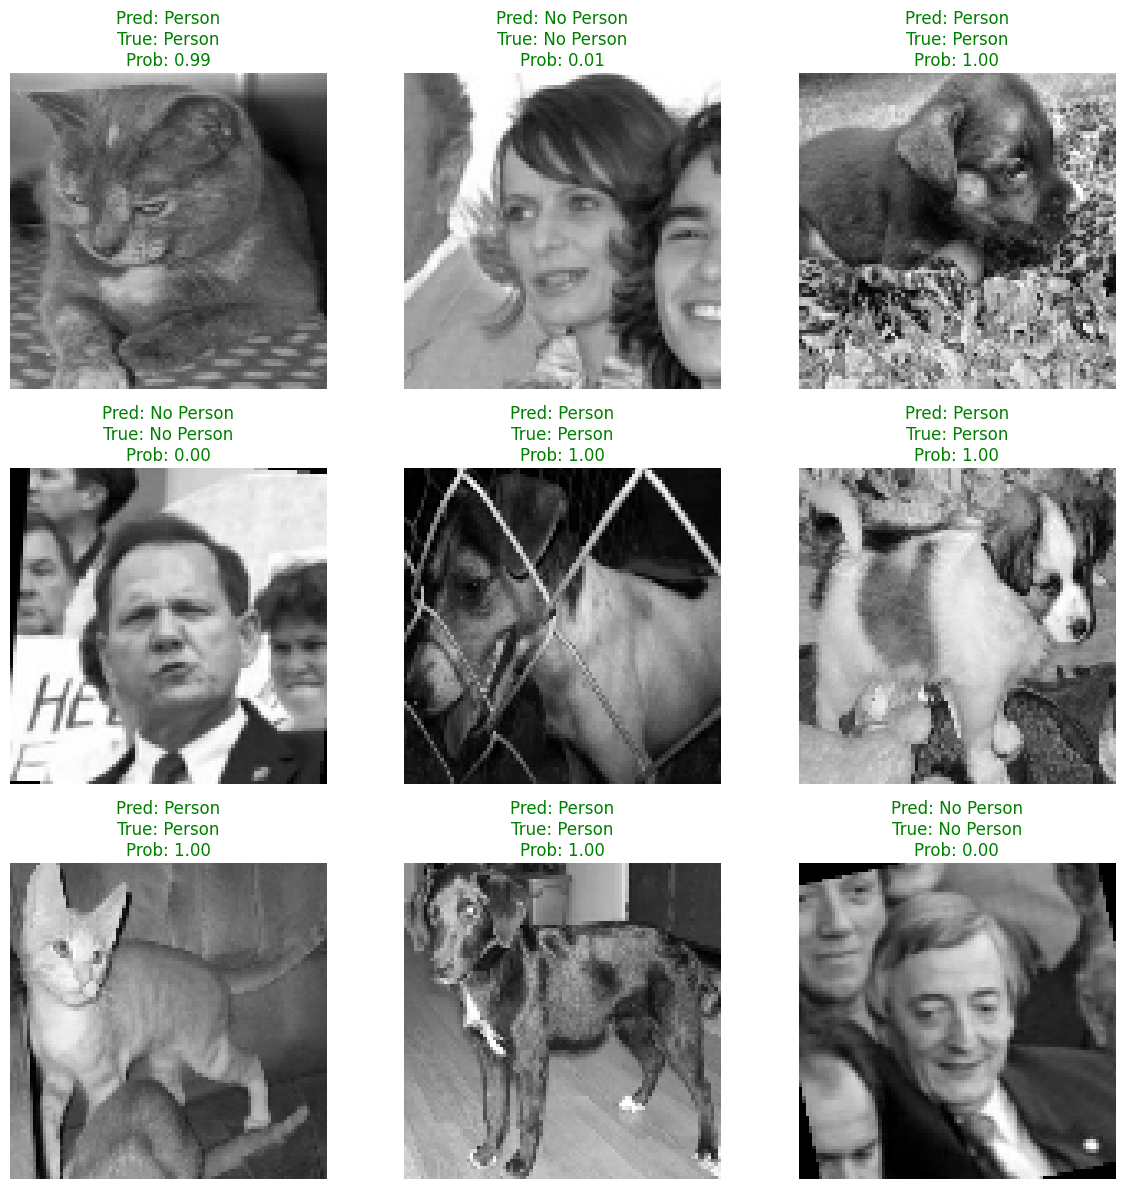

In [9]:
# گرفتن یک بچ (۳۲ عدد) از داده‌های تست
image_batch, label_batch = next(iter(test_dataset))

# گرفتن پیش‌بینی مدل برای این ۳۲ عکس
# خروجی مدل عددی بین 0 و 1 است (احتمال وجود انسان)
predictions = model.predict(image_batch)

class_names = ['No Person', 'Person']

plt.figure(figsize=(12, 12))
for i in range(9): # نمایش ۹ عکس اول از این بچ
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(tf.squeeze(image_batch[i]), cmap='gray')
    
    # تبدیل احتمال به برچسب 0 یا 1 (اگر بزرگتر از 0.5 بود یعنی انسان است)
    predicted_label = 1 if predictions[i][0] > 0.5 else 0
    true_label = int(label_batch[i].numpy())
    
    # اگر پیش‌بینی درست بود رنگ سبز، اگر غلط بود رنگ قرمز
    color = 'green' if predicted_label == true_label else 'red'
    
    title = f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}\nProb: {predictions[i][0]:.2f}"
    plt.title(title, color=color)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

In [2]:
import tensorflow as tf
import numpy as np

TEST_DATA_DIR = '../data/human-and-non-human/test_set'
IMG_SIZE = 96

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1, 
    color_mode="grayscale",
    shuffle=False 
)

interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

correct_predictions = 0
total_images = 0

print("\nشروع ارزیابی مدل بهینه‌شده...")

for images, labels in test_dataset:
    # ۱. فقط نرمال‌سازی می‌کنیم (بدون تبدیل به فرمت پیچیده Int8)
    input_data = (images.numpy() / 255.0).astype(np.float32)
    
    # ۲. اجرای مدل
    interpreter.set_tensor(input_details['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details['index'])
    
    # ۳. خروجی مستقیماً یک عدد اعشاری (درصد) است
    probability = output_data[0][0]
        
    # ۴. بررسی درستی پیش‌بینی
    predicted_label = 1 if probability > 0.5 else 0
    true_label = int(labels.numpy()[0])
    
    if predicted_label == true_label:
        correct_predictions += 1
        
    total_images += 1

accuracy = (correct_predictions / total_images) * 100
print(f"دقت نهایی مدل TFLite (Float I/O): {accuracy:.2f}%")

Found 2723 files belonging to 2 classes.

شروع ارزیابی مدل بهینه‌شده...
دقت نهایی مدل TFLite (Float I/O): 99.41%


Found 2723 files belonging to 2 classes.


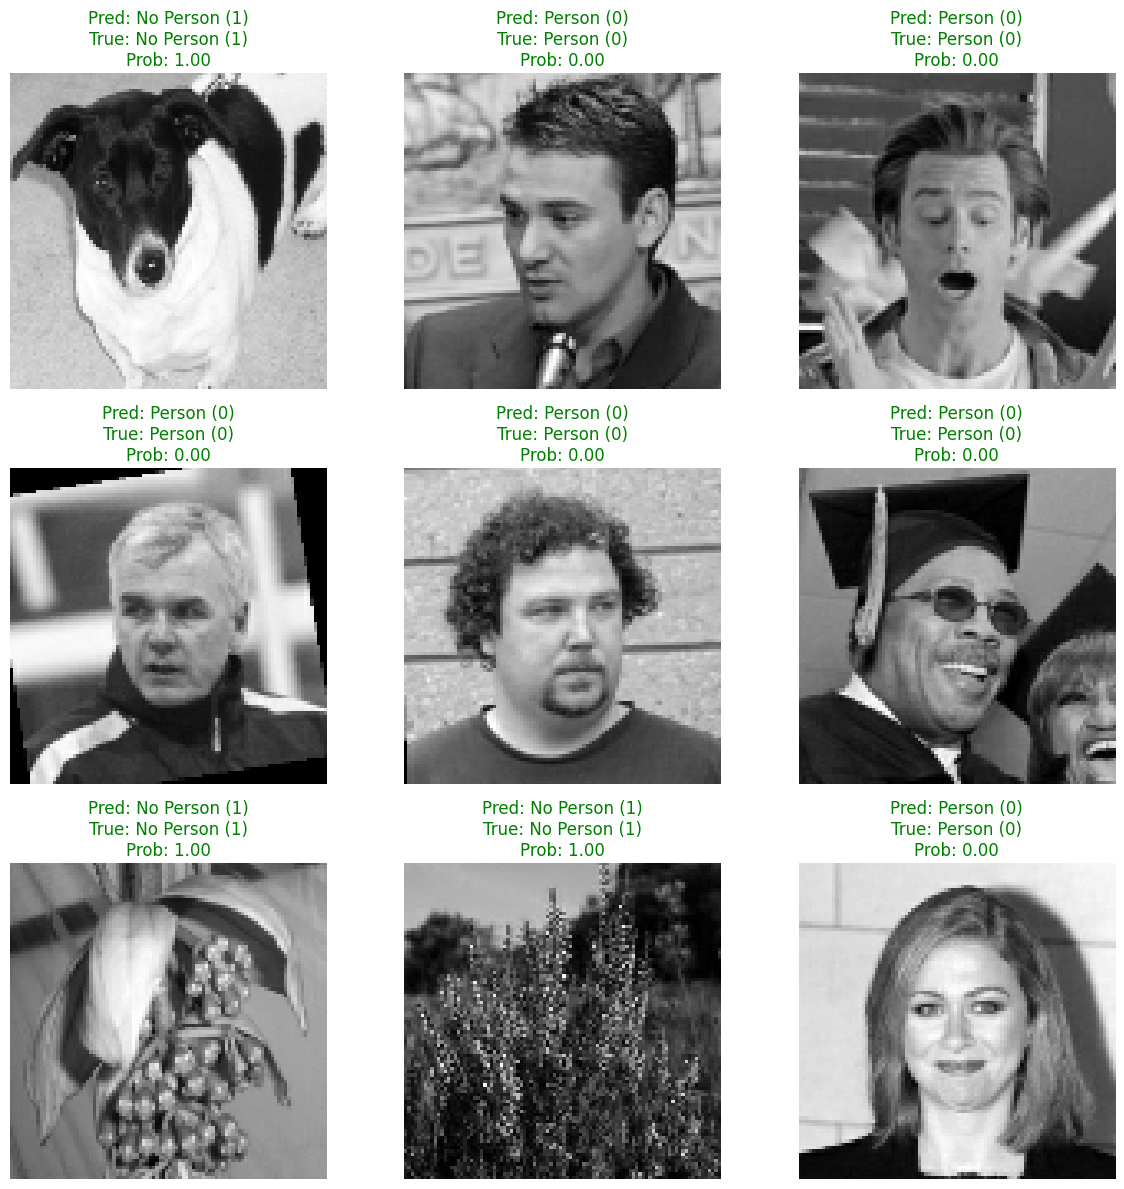

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# ۱. مسیر دیتاست تست (دقت کنید که مسیر را دقیقاً بر اساس پوشه‌بندی خودتان تنظیم کنید)
TEST_DATA_DIR = '../data/human-and-non-human/test_set'
IMG_SIZE = 96

# ۲. بارگذاری دیتاست با بچ‌سایز ۱ و حالت تصادفی
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1, 
    color_mode="grayscale",
    shuffle=True 
)

# ۳. راه‌اندازی مفسر TFLite
interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

# *** تغییر اصلی اینجاست: تطبیق لیبل‌ها با ترتیب الفبایی پوشه‌ها ***
class_names = ['Person (0)', 'No Person (1)'] 

plt.figure(figsize=(12, 12))

# ۴. گرفتن ۹ عکس اول و پردازش تک‌تک آن‌ها
for i, (image, label) in enumerate(test_dataset.take(9)):
    
    # الف) پیش‌پردازش (نرمال‌سازی اعشاری)
    input_data = (image.numpy() / 255.0).astype(np.float32)
    
    # ب) اجرای مدل TFLite
    interpreter.set_tensor(input_details['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details['index'])
    
    # ج) استخراج احتمال و پیش‌بینی
    probability = output_data[0][0]
    
    # اگر احتمال به ۱ نزدیک باشد یعنی کلاس 1 (No Person) و اگر به 0 نزدیک باشد یعنی کلاس 0 (Person)
    predicted_label = 1 if probability > 0.5 else 0
    true_label = int(label.numpy()[0])
    
    # د) تعیین رنگ بر اساس درستی تشخیص
    color = 'green' if predicted_label == true_label else 'red'
    
    # ه) رسم تصویر و اطلاعات
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(tf.squeeze(image), cmap='gray')
    
    title = f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}\nProb: {probability:.2f}"
    plt.title(title, color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import cv2
import numpy as np
import tensorflow as tf

# ۱. راه‌اندازی مفسر TFLite و بارگذاری مدل نهایی
interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

# ۲. روشن کردن دوربین
cap = cv2.VideoCapture(0)
print("دوربین روشن شد. برای خروج دکمه 'q' را از روی کیبورد فشار دهید.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("خطا در دریافت تصویر از وب‌کم!")
        break
        
    # ۳. پیش‌پردازش تصویر
    # الف) برش مربعی مرکز تصویر
    h, w, _ = frame.shape
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    cropped_frame = frame[start_y:start_y+min_dim, start_x:start_x+min_dim]
    
    # ب) تغییر سایز و سیاه‌سفید کردن
    resized = cv2.resize(cropped_frame, (96, 96))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    
    # ج) نرمال‌سازی مستقیم به صورت Float32
    input_data = (gray / 255.0).astype(np.float32)
    
    # اضافه کردن بعدهای ماتریس (تبدیل به فرمت 1, 96, 96, 1)
    input_data = np.expand_dims(input_data, axis=[0, 3])
    
    # ۴. اجرای مدل (Inference)
    interpreter.set_tensor(input_details['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details['index'])
    
    # ۵. دریافت درصد خروجی به صورت مستقیم
    probability = output_data[0][0]

    # ۶. نمایش نتیجه به صورت زنده روی تصویر وب‌کم
    label = "Person" if probability > 0.5 else "No Person"
    color = (0, 255, 0) if probability > 0.5 else (0, 0, 255)
    
    cv2.putText(frame, f"{label} ({probability:.2f})", (20, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
                
    cv2.imshow('TinyML Live Test', frame)
    
    # خروج با فشردن دکمه q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# آزادسازی منابع سیستم
cap.release()
cv2.destroyAllWindows()

دوربین روشن شد. برای خروج دکمه 'q' را از روی کیبورد فشار دهید.


تست با عکس روی برد

In [19]:
import cv2
import numpy as np

# ۱. آدرس یکی از عکس‌های تست خود را اینجا قرار دهید
IMAGE_PATH = "../data/human-and-non-human/test_set/non-humans/cat_0000.jpg"

# ۲. خواندن عکس، تغییر سایز به ۹۶ در ۹۶ و تبدیل به سیاه‌سفید
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (96, 96))

# ۳. ذخیره پیکسل‌های خام در یک فایل باینری (دقیقاً ۹۲۱۶ بایت خواهد شد)
img.tofile("sample_image.bin")
print("فایل تصویر باینری با موفقیت ساخته شد!")

فایل تصویر باینری با موفقیت ساخته شد!


In [ ]:
import machine
import sys
import math
import array

try:
    import model_config
except ImportError:
    print("فایل کانفیگ پیدا نشد.")

def sigmoid(x):
    if x < -70: return 0.0
    if x > 70: return 1.0
    return 1.0 / (1.0 + math.exp(-x))

def quantized_dense_layer_optimized(weight_file_path, image_file_path, biases, scale, zero_point, input_size, output_size):
    """
    پردازش کامل لایه بدون نیاز به لود کردن عکس یا وزن‌ها در رم (جلوگیری صددرصدی از MemoryError)
    """
    output = array.array('f', [0.0] * output_size)
    
    try:
        # باز کردن فایل وزن و فایل تصویر به صورت همزمان
        with open(weight_file_path, 'rb') as wf, open(image_file_path, 'rb') as imgf:
            
            for i in range(output_size):
                sum_val = biases[i]
                
                for j in range(input_size):
                    # ۱. خواندن پیکسل مربوط به این وزن از فایل تصویر
                    imgf.seek(j)
                    pixel_byte = imgf.read(1)
                    if not pixel_byte:
                        break
                    
                    # نرمال‌سازی درجا (مقدار بین 0.0 تا 1.0)
                    pixel_val = float(pixel_byte[0]) / 255.0
                    
                    # ۲. خواندن وزن مربوطه از فایل باینری وزن‌ها
                    target_index = j * output_size + i
                    wf.seek(target_index)
                    weight_byte = wf.read(1)
                    if not weight_byte:
                        break
                    
                    w_int8 = int(weight_byte[0])
                    if w_int8 > 127:
                        w_int8 -= 256
                        
                    w_float = (w_int8 - zero_point) * scale
                    
                    # ۳. محاسبه ضرب نقطه‌ای
                    sum_val += pixel_val * w_float
                    
                output[i] = sum_val
                
    except OSError as e:
        print("خطا در دسترسی به فایل‌ها:", e)
        
    return output

# اجرای مستقیم بدون نیاز به تخصیص رم حجیم
print("در حال پردازش هوشمند و بدون مصرف رم...")

final_logits = quantized_dense_layer_optimized(
    weight_file_path='w_6.bin', 
    image_file_path='sample_image.bin',
    biases=model_config.b_8,           
    scale=model_config.w_6_scale,      
    zero_point=model_config.w_6_zp,    
    input_size=16, 
    output_size=1
)

probability = sigmoid(final_logits[0])

print(f"احتمال (Probability): {probability:.4f}")
if probability > 0.5:
    print("نتیجه تشخیص: Person")
else:
    print("نتیجه تشخیص: No Person")

تست به همون روش برای لپتاپ

In [22]:
import os
import math
import cv2
from PIL import Image
import model_config

def sigmoid(x):
    if x < -70: return 0.0
    if x > 70: return 1.0
    return 1.0 / (1.0 + math.exp(-x))

def evaluate_single_image(image_path, weight_file_path, biases, scale, zero_point, input_size, output_size):
    """
    پردازش یک تصویر با روش استریمینگِ وزن‌ها و پیکسل‌ها
    """
    try:
        # خواندن و پیش‌پردازش تصویر با پشتیبانی از مسیرهای فارسی/ویندوز
        pil_img = Image.open(image_path).convert('L')
        img = cv2.resize(np_img := cv2.cvtColor(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cv2.COLOR_BGR2GRAY) if False else np.array(pil_img), (96, 96))
        
        # ذخیره موقت در حافظه یا آرایه برای خواندن استریمینگ (یا مستقیماً استفاده از آرایه ایمیج)
        # برای سرعت بیشتر در لپ‌تاپ، مستقیماً از آرایه resized استفاده می‌کنیم
        flatten_img = img.flatten()
        
        output = [0.0] * output_size
        with open(weight_file_path, 'rb') as wf:
            for i in range(output_size):
                sum_val = biases[i]
                for j in range(input_size):
                    if j >= len(flatten_img):
                        break
                    pixel_val = float(flatten_img[j]) / 255.0
                    
                    target_index = j * output_size + i
                    wf.seek(target_index)
                    weight_byte = wf.read(1)
                    if not weight_byte:
                        break
                    
                    w_int8 = weight_byte[0]
                    if w_int8 > 127:
                        w_int8 -= 256
                        
                    w_float = (w_int8 - zero_point) * scale
                    sum_val += pixel_val * w_float
                    
                output[i] = sum_val
        
        probability = sigmoid(output[0])
        return 1 if probability > 0.5 else 0
    except Exception as e:
        return None

def run_evaluation(base_test_dir):
    """
    پیمایش کل دیتاست تست و محاسبه Accuracy
    """
    print("شروع ارزیابی روی دیتاست تست...")
    
    # فرض بر این است که ساختار پوشه‌ها به شکل test_set/humans و test_set/non_humans است
    # آدرس‌ها را مطابق با ساختار پوشه پروژه خودت تنظیم کن
    human_dir = os.path.join(base_test_dir, "humans")
    non_human_dir = os.path.join(base_test_dir, "non-humans") # یا non_humans
    
    total_images = 0
    correct_predictions = 0
    
    # ۱. ارزیابی تصاویر انسان (برچسب واقعی = 1)
    if os.path.exists(human_dir):
        for img_name in os.listdir(human_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(human_dir, img_name)
                pred = evaluate_single_image(img_path, 'w_6.bin', model_config.b_8, model_config.w_6_scale, model_config.w_6_zp, 16, 1)
                
                if pred is not None:
                    total_images += 1
                    if pred == 1:
                        correct_predictions += 1
                        
    # ۲. ارزیابی تصاویر غیرانسان (برچسب واقعی = 0)
    if os.path.exists(non_human_dir):
        for img_name in os.listdir(non_human_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(non_human_dir, img_name)
                pred = evaluate_single_image(img_path, 'w_6.bin', model_config.b_8, model_config.w_6_scale, model_config.w_6_zp, 16, 1)
                
                if pred is not None:
                    total_images += 1
                    if pred == 0:
                        correct_predictions += 1

    if total_images > 0:
        accuracy = (correct_predictions / total_images) * 100
        print("\n--- نتیجه نهایی ارزیابی ---")
        print(f"کل تصاویر بررسی شده: {total_images}")
        print(f"تشخیص‌های صحیح: {correct_predictions}")
        print(f"دقت نهایی (Accuracy): {accuracy:.2f}%")
    else:
        print("هیچ عکسی در مسیرهای مشخص شده یافت نشد! مسیر پوشه تست را بررسی کنید.")

if __name__ == "__main__":
    # آدرس پوشه test_set خودت را اینجا وارد کن
    TEST_SET_DIR = "../data/human-and-non-human/test_set"
    run_evaluation(TEST_SET_DIR)

شروع ارزیابی روی دیتاست تست...

--- نتیجه نهایی ارزیابی ---
کل تصاویر بررسی شده: 2723
تشخیص‌های صحیح: 1051
دقت نهایی (Accuracy): 38.60%


تست مدل اصلی

In [4]:
import cv2
import numpy as np
import tensorflow as tf

# ---------------------------------------------------------
# ۱. بارگذاری مدل اصلی کراس (مدل بیس و قوی)
# ---------------------------------------------------------
# نام فایل مدل اصلی خود را اینجا قرار دهید (مثلاً model.h5 یا model.keras)
MODEL_PATH = "human_detection_base.keras" 

print(f"در حال بارگذاری مدل اصلی از مسیر: {MODEL_PATH} ...")
model = tf.keras.models.load_model(MODEL_PATH)
print("مدل با موفقیت بارگذاری شد!")

# ---------------------------------------------------------
# ۲. روشن کردن وب‌کم
# ---------------------------------------------------------
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("خطا: وب‌کم پیدا نشد!")
    exit()

print("وب‌کم روشن شد. برای خروج دکمه 'q' را فشار دهید.")

while True:
    ret, frame = cap.read()
    if not ret:
        continue

    # ---------------------------------------------------------
    # ۳. پیش‌پردازش تصویر (دقیقاً چیزی که مدل اصلی می‌بیند)
    # ---------------------------------------------------------
    # تبدیل به سیاه‌سفید
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # تغییر سایز به 96x96
    resized_frame = cv2.resize(gray_frame, (96, 96))
    
    # ساختن آرایه ورودی با ابعاد صحیح (1, 96, 96, 1)
    input_data = np.expand_dims(resized_frame, axis=0)
    input_data = np.expand_dims(input_data, axis=-1)
    
    # نرمال‌سازی تصویر برای مدل اصلی (اعداد بین 0 و 1)
    input_data = input_data.astype('float32') / 255.0

    # ---------------------------------------------------------
    # ۴. اجرای شبکه عصبی اصلی
    # ---------------------------------------------------------
    # در کراس، خروجی مستقیماً احتمال را برمی‌گرداند (به شرطی که لایه آخر sigmoid باشد)
    prediction = model.predict(input_data, verbose=0)
    probability = prediction[0][0]

    # ---------------------------------------------------------
    # ۵. نمایش گرافیکی نتایج
    # ---------------------------------------------------------
    if probability > 0.5:
        label = f"Person ({probability*100:.1f}%)"
        color = (0, 255, 0) # سبز برای انسان
    else:
        label = f"No Person ({probability*100:.1f}%)"
        color = (0, 0, 255) # قرمز برای عدم وجود انسان

    # نوشتن متن روی فریم اصلی
    cv2.putText(frame, label, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
    
    # زوم کردن تصویری که مدل می‌بیند برای نمایش بهتر روی مانیتور
    model_view_display = cv2.resize(resized_frame, (400, 400), interpolation=cv2.INTER_NEAREST)
    
    # اضافه کردن یک متن راهنما روی تصویر دیدِ مدل
    cv2.putText(model_view_display, "What Base Model Sees", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    # نمایش پنجره‌ها
    cv2.imshow("Main Webcam (Original)", frame)
    cv2.imshow("Base Model View (96x96)", model_view_display)

    # خروج با دکمه 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

در حال بارگذاری مدل اصلی از مسیر: human_detection_base.keras ...
مدل با موفقیت بارگذاری شد!
وب‌کم روشن شد. برای خروج دکمه 'q' را فشار دهید.


In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf

def evaluate_tflite_accuracy(model_path, base_test_dir):
    print(f"در حال بارگذاری مدل {model_path} ...")
    
    # هشدارها (Warnings) تنسورفلو مهم نیستند، فقط اطلاع‌رسانی هستند
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    is_input_quantized = input_details['dtype'] == np.int8
    is_output_quantized = output_details['dtype'] == np.int8
    
    if is_input_quantized:
        in_scale, in_zp = input_details['quantization']
    if is_output_quantized:
        out_scale, out_zp = output_details['quantization']

    human_dir = os.path.join(base_test_dir, "humans")
    non_human_dir = os.path.join(base_test_dir, "non-humans")
    
    total_images = 0
    correct_predictions = 0

    def process_image(img_path, true_label):
        nonlocal total_images, correct_predictions
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: return
            
        img = cv2.resize(img, (96, 96))
        
        input_data = np.expand_dims(img, axis=0)
        input_data = np.expand_dims(input_data, axis=-1)
        
        if is_input_quantized:
            input_data = (input_data / 255.0 / in_scale + in_zp).astype(np.int8)
        else:
            input_data = (input_data / 255.0).astype(np.float32)
            
        interpreter.set_tensor(input_details['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])[0][0]
        
        # خروجی TFLite خودش احتمال (Probability) است، فقط باید دیکوانتیزه شود
        if is_output_quantized:
            probability = (output_data - out_zp) * out_scale
        else:
            probability = output_data
            
        # فرض استاندارد کراس: انسان = 0 ، غیر انسان = 1
        # اگر probability کمتر از 0.5 باشد یعنی تمایل به کلاس 0 (انسان) دارد
        prediction = 1 if probability > 0.5 else 0
        
        total_images += 1
        if prediction == true_label:
            correct_predictions += 1

    print("در حال ارزیابی تصاویر انسان (کلاس 0)...")
    if os.path.exists(human_dir):
        for img_name in os.listdir(human_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                process_image(os.path.join(human_dir, img_name), true_label=0)

    print("در حال ارزیابی تصاویر غیر انسان (کلاس 1)...")
    if os.path.exists(non_human_dir):
        for img_name in os.listdir(non_human_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                process_image(os.path.join(non_human_dir, img_name), true_label=1)

    if total_images > 0:
        accuracy = (correct_predictions / total_images) * 100
        print("\n" + "="*40)
        print("گزارش نهایی ارزیابی TFLite")
        print("="*40)
        print(f"کل تصاویر ارزیابی شده: {total_images}")
        print(f"تشخیص‌های کاملاً صحیح: {correct_predictions}")
        print(f"دقت واقعی مدل کوانتیزه‌شده: {accuracy:.2f}%")
        print("="*40)
    else:
        print("هیچ عکسی پیدا نشد!")

if __name__ == "__main__":
    TEST_SET_DIR = r"D:\Programming\AI Projects\TinyML_Human_Detection\data\human-and-non-human\test_set"
    evaluate_tflite_accuracy(model_path="model.tflite", base_test_dir=TEST_SET_DIR)

در حال بارگذاری مدل model.tflite ...
در حال ارزیابی تصاویر انسان (کلاس 0)...
در حال ارزیابی تصاویر غیر انسان (کلاس 1)...

گزارش نهایی ارزیابی TFLite
کل تصاویر ارزیابی شده: 2723
تشخیص‌های کاملاً صحیح: 2707
دقت واقعی مدل کوانتیزه‌شده: 99.41%


In [ ]:
import tensorflow as tf

def inspect_tflite_model(model_path="model.tflite"):
    print(f"در حال کالبدشکافی مدل: {model_path}\n")
    
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    tensor_details = interpreter.get_tensor_details()
    
    # چاپ هدر جدول
    print(f"{'Index':<6} | {'Shape':<22} | {'Data Type':<12} | {'Tensor Name'}")
    print("-" * 90)
    
    for detail in tensor_details:
        index = detail['index']
        shape = str(detail['shape'])
        
        # استخراج نام نوع داده (مثل int8 یا int32)
        dtype = detail['dtype'].__name__
        
        name = detail['name']
        
        print(f"{index:<6} | {shape:<22} | {dtype:<12} | {name}")

if __name__ == "__main__":
    inspect_tflite_model()

In [11]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

# استخراج وزن‌ها (ایندکس 13) و ذخیره به صورت باینری خام
w_tensor = interpreter.get_tensor(13)
w_tensor.tofile("conv1_w.bin")

# استخراج تنظیمات کوانتیزیشن وزن‌ها
scale, zp = interpreter.get_tensor_details()[13]['quantization']

# استخراج بایاس‌ها (ایندکس 12)
biases = interpreter.get_tensor(12).tolist()

print("فایل conv1_w.bin با موفقیت ساخته شد.")
print("-" * 40)
print(f"لطفاً این مقادیر را در اسکریپت بنچمارک کپی کنید:")
print(f"biases = {biases}")
print(f"scale = {scale}")
print(f"zp = {zp}")
print("-" * 40)

فایل conv1_w.bin با موفقیت ساخته شد.
----------------------------------------
لطفاً این مقادیر را در اسکریپت بنچمارک کپی کنید:
biases = [1649, -20843, 4720, -509, -1472, -2016, 20311, 6410]
scale = 0.0
zp = 0
----------------------------------------
